# 1. Bussines Case Discovery

## 1.1 Contexto del Negocio

Eres parte de un equipo de análisis en una firma de inversión inmobiliaria. La empresa busca mejorar la precisión en la valoración de propiedades con el objetivo de maximizar la rentabilidad y minimizar riesgos. En este mercado, errores en la estimación de precios pueden resultar en pérdidas millonarias.

La empresa dispone de un dataset histórico con las siguientes variables:
- Características de entrada
    - area: Área total de la vivienda en pies cuadrados.
    - bedrooms: Número de habitaciones.
    - bathrooms: Número de baños.
    - stories: Número de pisos.
    - mainroad: Si la casa está en una calle principal (Sí/No).
    - guestroom: Si tiene habitación de invitados (Sí/No).
    - basement: Si cuenta con sótano (Sí/No).
    - hotwaterheating: Si tiene calefacción de agua caliente (Sí/No).
    - airconditioning: Si cuenta con aire acondicionado (Sí/No).
    - parking: Número de plazas de estacionamiento.
    - prefarea: Si está en una zona preferencial (Sí/No).
    - furnishingstatus: Estado del mobiliario (Amueblado, Semiamueblado, No amueblado).
- Variable objetivo
    - price: Precio de venta de la propiedad (variable continua a predecir).

## 1.2 Objetivo del Proyecto

Desarrollar un modelo de redes neuronales para predecir los precios de las viviendas con una precisión superior a los métodos tradicionales como la regresión lineal.

## 1.3 Stakeholders y Requisitos

- Inversores: Buscan predicciones con un margen de error inferior al 15%.
- Equipo Legal: Exigen que el modelo sea interpretable para justificar decisiones en auditorías.
- Equipo Técnico: La implementación debe ser escalable y compatible con entornos de nube (AWS/GCP), utilizando Contenedores Docker.

## 1.4 Métricas de Éxito
- Error cuadrático medio (RMSE): Inferior al 15% del precio promedio de las viviendas.
- Coeficiente de determinación (R²): Mayor a 0.60.

## 1.5 Desafíos Anticipados
- Multicolinealidad: Variables como area, bedrooms y bathrooms pueden estar correlacionadas.
- Distribuciones sesgadas: Variables binarias y categóricas pueden necesitar codificación adecuada.
- Sobreajuste: La red neuronal puede memorizar datos en lugar de generalizar.


# 2. Data Processing

## 2.1 Carga y Exploración Inicial

El alumno deberá cargar el dataset, visualizar las primeras filas y explorar la distribución de los datos con histogramas y diagramas de caja. Se recomienda el uso de pandas y matplotlib.

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Housing.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/housing-prices-dataset",
  file_path
)

c:\Users\Usuario\Desktop\IAG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Usuario\AppData\Local\Temp\ipykernel_14776\1758182739.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 29.3k/29.3k [00:00<00:00, 810kB/s]


### Primeras 5 filas

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Valores Nulos

In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

El datasaet **NO** presenta valores nulos en niguna columna

### Distribución de los Datos

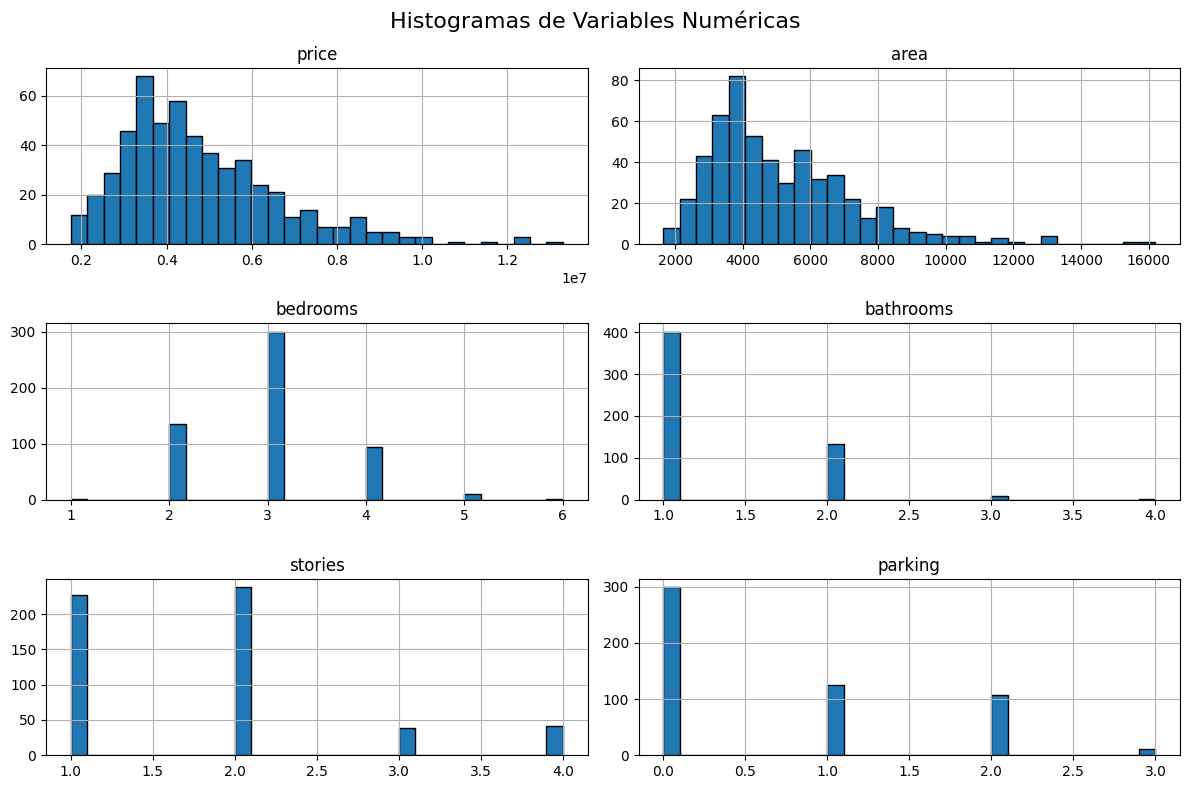

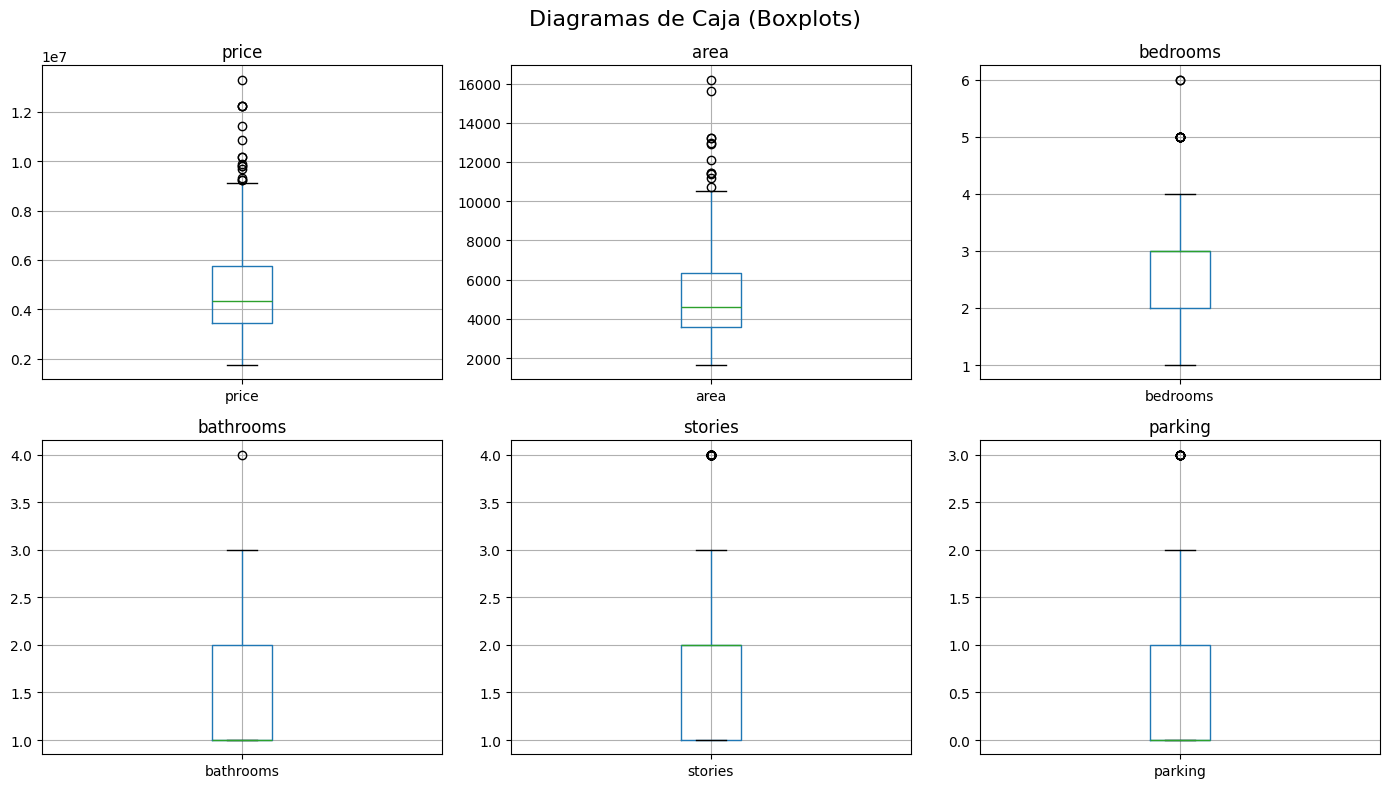

In [5]:
import matplotlib.pyplot as plt

# Filtramos solo las columnas numéricas para los gráficos
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Exploramos la distribución para ver colas largas
df_numeric.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle('Histogramas de Variables Numéricas', fontsize=16)
plt.tight_layout()
plt.show()

# Exploramos más mediante Boxplots para indetificar valores atípicos
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(df_numeric.columns):
    df_numeric.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Diagramas de Caja (Boxplots)', fontsize=16)
plt.tight_layout()
plt.show()

Tras analizar las gráficas, podemos observar que tanto el precio como el área presentan una cola larga hacia la derecha. Lo que nos representa que la mayoría de casas tiene un precio medio de uno 4 millones $(0.4 * 10^7)$ y una superfice de $4000 pies^2$. En cuanto a los baños la media está en uno y las habitaciones en 3. Aunque también hay valores atípicos llegando a tener 3/4 baños y 5/6 habitaciones y en cuanto al precio y el area presentan valores atípicos a partir de los 10 millones $(1.0 * 10^7)$ de precio y los $10000 pies^2$.

## 2.2 Análisis de Correlación

El alumno generará una matriz de correlación para analizar relaciones entre variables. Se sugiere utilizar seaborn.

Pistas:
- Evaluar qué variables tienen alta correlación con price.
- Considerar la eliminación de variables redundantes.

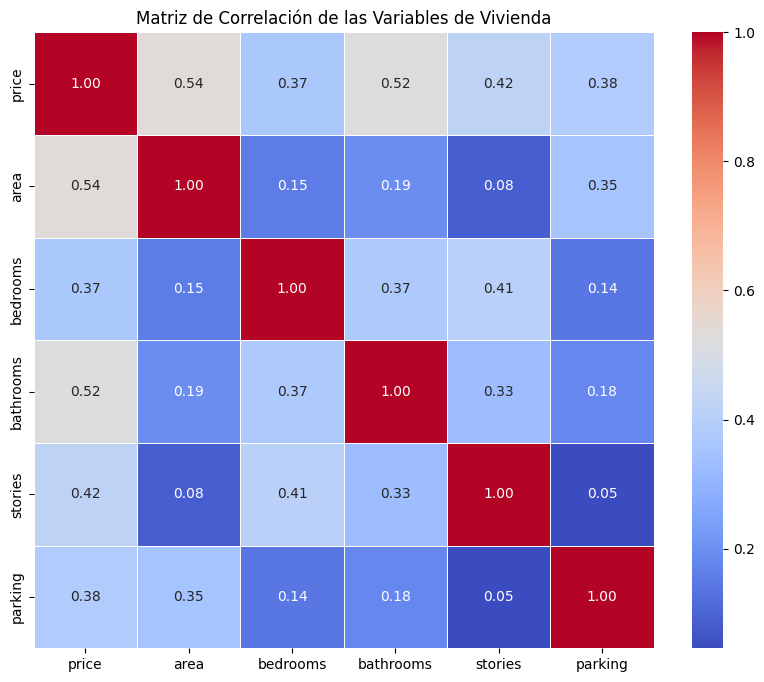

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos la matriz de correlación solo para variables numéricas
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.7)
plt.title('Matriz de Correlación de las Variables de Vivienda')
plt.show()

Si observamos solamente la columna del precio vemos: 

- La correlación más alta es el area (0.54), es decir, los pies cuadrados son el factor número uno para determinar el precio de una casa en este conjunto de datos. 
- Los baños también son un bien muy preciado (0.52). Añadir baños incrementa el valor de la propiedad significativamente. 
- El número de pisos también tiene un peso importante (0.42), aunque menor que el área total o los baños.
- Tener plazas de garaje suma valor (0.38), pero es una correlación moderada.
- El número de habitaciones tiene la correlación más baja de las variables numéricas (0.37). Podría ser porque pese a tener una casa con muchas habitaciones sean muy pequeñas, lo que implica no tener mucho area y no sube tanto el precio como tener baños extra o una casa más grande.

**Por el momento no se contempla la eliminación de variables porque ninguna tiene una correlación muy cercana a 0.**

## 2.3 Preprocesamiento de Datos

### Manejo de valores faltantes: Si existen, imputarlos con la mediana o la moda según el tipo de variable

**No existen valores faltantes por lo que no hay ningún procesamiento a realizar**

### Codificación de variables categóricas: Convertir mainroad, guestroom, basement, etc., en valores numéricos

In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Convertimos los booleanos que genera get_dummies a 1/0
df['furnishingstatus_semi-furnished'] = df['furnishingstatus_semi-furnished'].astype(int)
df['furnishingstatus_unfurnished'] = df['furnishingstatus_unfurnished'].astype(int)

# Mapeamos las variables booleanas a 1/0
columnas_binarias = ['mainroad', 'guestroom', 'basement', 
                     'hotwaterheating', 'airconditioning', 'prefarea']

for col in columnas_binarias:
    df[col] = df[col].map({'yes': 1, 'no': 0})

### Normalización: Escalar las variables numéricas con StandardScaler o MinMaxScaler

In [8]:
# Seleccionamos las columnas numéricas originales que queremos escalar
columnas_a_escalar = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Inicializamos el escalador
scaler = MinMaxScaler()

# Ajustamos y transformamos los datos
df[columnas_a_escalar] = scaler.fit_transform(df[columnas_a_escalar])

# --- RESULTADO FINAL ---
print("Dataset después del preprocesamiento:")
display(df.head())

Dataset después del preprocesamiento:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.000000,0.396564,0.6,0.333333,0.666667,1,0,0,0,1,0.666667,1,0,0
1,0.909091,0.502405,0.6,1.000000,1.000000,1,0,0,0,1,1.000000,0,0,0
2,0.909091,0.571134,0.4,0.333333,0.333333,1,0,1,0,0,0.666667,1,1,0
3,0.906061,0.402062,0.6,0.333333,0.333333,1,0,1,0,1,1.000000,1,0,0
4,0.836364,0.396564,0.6,0.000000,0.333333,1,1,1,0,1,0.666667,0,0,0


## 2.4 División Train-Test

El alumno deberá dividir los datos en entrenamiento y prueba (80/20). Se recomienda usar train_test_split de sklearn.

In [9]:
from sklearn.model_selection import train_test_split

# Separamos las características de la variable objetivo
X = df.drop('price', axis=1)
y = df['price']              

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Comprobamos los tamaños
print("--- Tamaños de los conjuntos ---")
print(f"Total de datos originales: {df.shape[0]} filas")
print(f"Entrenamiento (X_train, y_train): {X_train.shape[0]} filas")
print(f"Prueba (X_test, y_test): {X_test.shape[0]} filas")

--- Tamaños de los conjuntos ---
Total de datos originales: 545 filas
Entrenamiento (X_train, y_train): 436 filas
Prueba (X_test, y_test): 109 filas


# 3. Model Planning

## 3.1 Definición del Problema

- Tipo de Modelo: Regresión con red neuronal.
- Entrada: 12 características preprocesadas.
- Salida: Predicción del precio.

## 3.2 Arquitectura de la Red

El alumno deberá diseñar una red neuronal con:
- Capa de Entrada: 12 neuronas (una por feature). 
- Capas Ocultas: Dos capas densas con activación ReLU.
- Capa de Salida: 1 neurona con activación lineal.

## 3.3 Función de Pérdida y Optimizador
- Loss Function: Error cuadrático medio (MSE).
- Optimizadores a comparar: Adam y SGD con momentum.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, SGD

# Creamos una función para poder generar un modelo "limpio" en cada vuelta del K-Fold
def construir_modelo(tipo_optimizador):
    
    # Arquitectura de la Red
    dim_entrada = X.shape[1]
    
    modelo = Sequential([
        Input(shape=(dim_entrada,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    
    # Función de Pérdida y Optimizador
    if tipo_optimizador == 'adam':
        opt = Adam(learning_rate=0.001)
    elif tipo_optimizador == 'sgd':
        opt = SGD(learning_rate=0.01, momentum=0.9)
        
    # Compilamos usando MSE como Loss
    modelo.compile(optimizer=opt, loss='mse', metrics=['mae'])
    
    return modelo

## 3.4 Evaluación del Modelo
Se analizarán métricas como MAE, RMSE y R², y se usará validación cruzada (K-Fold con k=5).

In [11]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from tensorflow.keras import backend as K

# Configuramos la validación cruzada con k=5
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Diccionarios para guardar los resultados de ambos optimizadores
resultados_adam = {'mae': [], 'rmse': [], 'r2': []}
resultados_sgd = {'mae': [], 'rmse': [], 'r2': []}

print("Iniciando Evaluación con K-Fold (k=5)...")

# Bucle de evaluación
for fold, (train_index, val_index) in enumerate(kf.split(X)):

    # Limpiamos la sesión de Keras para evitar el warning de "retracing" y liberar RAM
    K.clear_session()

    print(f"Entrenando pliegue {fold + 1}/5...")
    
    # Separar datos del pliegue actual
    X_train_kf, X_val_kf = X.iloc[train_index], X.iloc[val_index]
    y_train_kf, y_val_kf = y.iloc[train_index], y.iloc[val_index]
    
    # --- Evaluación del Modelo con ADAM ---
    modelo_adam = construir_modelo('adam')
    modelo_adam.fit(X_train_kf, y_train_kf, epochs=50, batch_size=16, verbose=0)
    pred_adam = modelo_adam.predict(X_val_kf, verbose=0)
    
    resultados_adam['mae'].append(mean_absolute_error(y_val_kf, pred_adam))
    resultados_adam['rmse'].append(np.sqrt(mean_squared_error(y_val_kf, pred_adam)))
    resultados_adam['r2'].append(r2_score(y_val_kf, pred_adam))
    
    # --- Evaluación del Modelo con SGD ---
    modelo_sgd = construir_modelo('sgd')
    modelo_sgd.fit(X_train_kf, y_train_kf, epochs=50, batch_size=16, verbose=0)
    pred_sgd = modelo_sgd.predict(X_val_kf, verbose=0)
    
    resultados_sgd['mae'].append(mean_absolute_error(y_val_kf, pred_sgd))
    resultados_sgd['rmse'].append(np.sqrt(mean_squared_error(y_val_kf, pred_sgd)))
    resultados_sgd['r2'].append(r2_score(y_val_kf, pred_sgd))

print("\n" + "="*30)
print("     RESULTADOS FINALES     ")
print("="*30)
print("OPTIMIZADOR ADAM:")
print(f"MAE Promedio:  {np.mean(resultados_adam['mae']):.4f}")
print(f"RMSE Promedio: {np.mean(resultados_adam['rmse']):.4f}")
print(f"R² Promedio:   {np.mean(resultados_adam['r2']):.4f}")
print("-" * 30)
print("OPTIMIZADOR SGD (Momentum):")
print(f"MAE Promedio:  {np.mean(resultados_sgd['mae']):.4f}")
print(f"RMSE Promedio: {np.mean(resultados_sgd['rmse']):.4f}")
print(f"R² Promedio:   {np.mean(resultados_sgd['r2']):.4f}")
print("="*30)

Iniciando Evaluación con K-Fold (k=5)...

Entrenando pliegue 1/5...
Entrenando pliegue 2/5...
Entrenando pliegue 3/5...
Entrenando pliegue 4/5...
Entrenando pliegue 5/5...

     RESULTADOS FINALES     
OPTIMIZADOR ADAM:
MAE Promedio:  0.0776
RMSE Promedio: 0.1030
R² Promedio:   0.5465
------------------------------
OPTIMIZADOR SGD (Momentum):
MAE Promedio:  0.0764
RMSE Promedio: 0.1016
R² Promedio:   0.5638


Como podemos observar **SDG** es superior al optimizador ADAM, ya que tiene un $R^2$ superior, lo que significa que explica casi el 56% de la variabilidad del precio de las casas. Además el error (MAE Y RMSE) son más bajos en **SDG** que en ADAMS, por lo que nos quedaremos con el optimizador **SDG**

# 4. Model Building and Selection

## 4.1 Implementación en Keras
El alumno construirá el modelo usando keras.Sequential().

## 4.2 Entrenamiento del Modelo

Entrenar la red con un número adecuado de épocas y un tamaño de batch óptimo, asegurando una validación efectiva para evitar sobreajuste.

Ejemplo: 100 épocas con `batch_size=32` y validación del `20%`.

## 4.3 Experimentación de Hiperparámetros
- Probar distintas tasas de aprendizaje (`0.001`, `0.0001`).
- Comparar `batch_size=16` vs `64`.
- Aplicar regularización con `Dropout` o `L2`.

## 4.4 Evaluación en Conjunto de Test
El alumno comparará las métricas finales con las del conjunto de entrenamiento para verificar si hay sobreajuste.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from sklearn.metrics import mean_absolute_error, r2_score

# Implementacion en Keras
def construir_modelo_final(learning_rate, usar_regularizacion=False):
    dim_entrada = X_train.shape[1]
    
    modelo = Sequential()
    modelo.add(Input(shape=(dim_entrada,)))
    
    if usar_regularizacion:        
        modelo.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
        modelo.add(Dropout(0.2)) 
        modelo.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
    else:        
        modelo.add(Dense(64, activation='relu'))
        modelo.add(Dense(32, activation='relu'))
        
    modelo.add(Dense(1, activation='linear'))
        
    opt = SGD(learning_rate=learning_rate, momentum=0.9)
    modelo.compile(optimizer=opt, loss='mse', metrics=['mae'])
    
    return modelo

# Experimentación de Hiperparámetros
experimentos = [
    {'nombre': '1. Base (LR=0.001, Batch=32)', 'lr': 0.001, 'batch': 32, 'reg': False},
    {'nombre': '2. LR Bajo (LR=0.0001, Batch=32)', 'lr': 0.0001, 'batch': 32, 'reg': False},
    {'nombre': '3. Batch Pequeño (Batch=16)', 'lr': 0.001, 'batch': 16, 'reg': False},
    {'nombre': '4. Batch Grande (Batch=64)', 'lr': 0.001, 'batch': 64, 'reg': False},
    {'nombre': '5. Regularizado (L2 + Dropout)', 'lr': 0.001, 'batch': 32, 'reg': True}
]

resultados = []
print("Iniciando entrenamiento y validación de los 5 experimentos...\n")

# Entrenamiento del Modelo
for exp in experimentos:
    K.clear_session()
    
    modelo = construir_modelo_final(learning_rate=exp['lr'], usar_regularizacion=exp['reg'])
    
    # Entrenamos con 100 épocas y usamos X_test como validación
    historia = modelo.fit(X_train, y_train, 
                          epochs=100, 
                          batch_size=exp['batch'], 
                          validation_data=(X_test, y_test), 
                          verbose=0)
    
    pred_train = modelo.predict(X_train, verbose=0)
    pred_test = modelo.predict(X_test, verbose=0)
    
    mae_train = mean_absolute_error(y_train, pred_train)
    mae_test = mean_absolute_error(y_test, pred_test)
    r2_test = r2_score(y_test, pred_test)
    
    resultados.append({
        'Modelo': exp['nombre'],
        'MAE Train': round(mae_train, 4),
        'MAE Test': round(mae_test, 4),
        'Diferencia (Test - Train)': round(mae_test - mae_train, 4),
        'R² Test': round(r2_test, 4)
    })
    
    print(f"✔️ {exp['nombre']} completado.")

# --- RESULTADOS FINALES ---
df_resultados = pd.DataFrame(resultados)
print("\n=== EVALUACIÓN DE SOBREAJUSTE E HIPERPARÁMETROS ===")
display(df_resultados)

Iniciando entrenamiento y validación de los 5 experimentos...

✔️ 1. Base (LR=0.001, Batch=32) completado.
✔️ 2. LR Bajo (LR=0.0001, Batch=32) completado.
✔️ 3. Batch Pequeño (Batch=16) completado.
✔️ 4. Batch Grande (Batch=64) completado.
✔️ 5. Regularizado (L2 + Dropout) completado.

=== EVALUACIÓN DE SOBREAJUSTE E HIPERPARÁMETROS ===


,Modelo,MAE Train,MAE Test,Diferencia (Test - Train),R² Test
0,"1. Base (LR=0.001, Batch=32)",0.0682,0.0877,0.0195,0.6157
1,"2. LR Bajo (LR=0.0001, Batch=32)",0.0896,0.1163,0.0267,0.3704
2,3. Batch Pequeño (Batch=16),0.0619,0.0859,0.0240,0.6156
3,4. Batch Grande (Batch=64),0.0716,0.0903,0.0187,0.5557
4,5. Regularizado (L2 + Dropout),0.0706,0.0929,0.0223,0.5429


Tras la **Experimentación de Hiperparámetros** nos quedaremos con la siguiente configuración para el modelo:

- **Optimizador SGD:** por los motivos que comentamos en el punto anterior. 
- **Modelo 1:** Learning Rate de `0.001` y batch_size de `32` sin regularización agresiva, ya que es el que mejor resultados ha obtenido. Con $R^2 = 0.61$ es capaz de explicar entorno al 61% del comprtamiento del precio, acompañado de la diferencia de error más baja (0.0195). Lo que indica que es más estable, ha memorizado menos los datos de entrenamiento y será capaz de generalizar mejor.

# 5. Presentación de Resultados

## 5.1 Evaluación de Predicciones
El alumno deberá analizar la calidad de las predicciones utilizando gráficos de dispersión, líneas de tendencia y métricas clave como RMSE y R². Se recomienda interpretar visualmente cómo se alinean las predicciones con los valores reales y detectar posibles patrones de error.

## 5.2 Análisis de Errores
Se identificarán las predicciones con errores significativos, especialmente aquellas con desviaciones superiores al 10% del precio real. El alumno deberá investigar si estos errores se deben a outliers, falta de representatividad en los datos de entrenamiento o limitaciones del modelo.

## 5.3 Comparación con Baseline (OPCIONAL)
Para evaluar la efectividad del modelo, se compararán sus resultados con un modelo de regresión lineal tradicional. Se analizarán diferencias en RMSE, R² y la distribución de errores para justificar el uso de una red neuronal frente a métodos más simples.

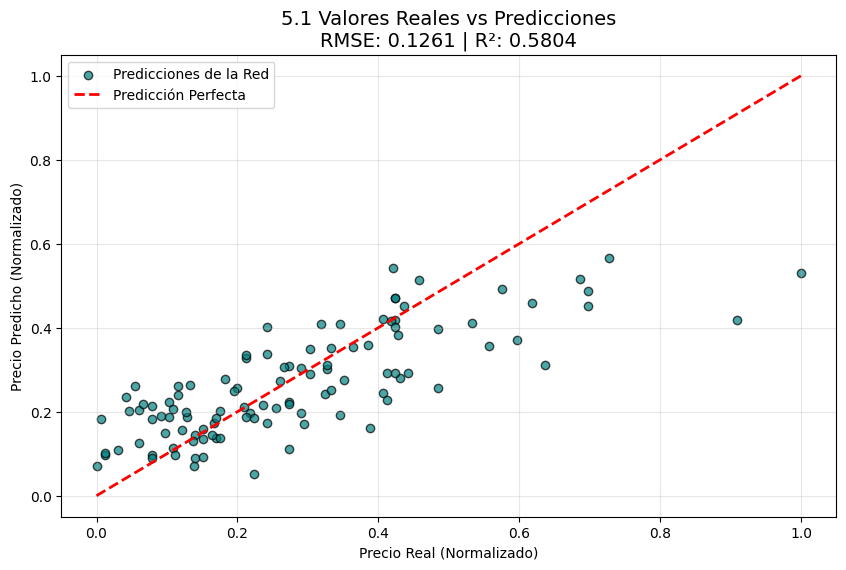


--- 5.2 ANÁLISIS DE ERRORES ---
Total de casas evaluadas en test: 109
Casas con desviación > 10%: 88 (80.7%)

--- 5.3 COMPARATIVA: RED NEURONAL vs REGRESIÓN LINEAL ---
🎯 RED NEURONAL:
   RMSE: 0.1261  |  R²: 0.5804
📉 REGRESIÓN LINEAL:
   RMSE: 0.1147  |  R²: 0.6529

⚠️ Conclusión: La Regresión Lineal tradicional empata o supera a la Red Neuronal para este dataset.


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Entrenar el modelo definitivo
K.clear_session()
modelo_final = construir_modelo_final(learning_rate=0.001, usar_regularizacion=False)
modelo_final.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

# Aplanamos las predicciones para que sean un array 1D igual que y_test
y_pred_nn = modelo_final.predict(X_test, verbose=0).flatten() 

# Evalulacaión de Predicciones
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.7, color='teal', edgecolor='k', label='Predicciones de la Red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')

plt.title(f'5.1 Valores Reales vs Predicciones\nRMSE: {rmse_nn:.4f} | R²: {r2_nn:.4f}', fontsize=14)
plt.xlabel('Precio Real (Normalizado)')
plt.ylabel('Precio Predicho (Normalizado)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Análisis de Errores
error_porcentual = (np.abs(y_pred_nn - y_test) / (y_test + 1e-8)) * 100

df_errores = pd.DataFrame({
    'Precio_Real_Norm': y_test,
    'Precio_Predicho_Norm': y_pred_nn,
    'Error_Porcentual': error_porcentual
})

# Filtramos los mayores al 10%
errores_graves = df_errores[df_errores['Error_Porcentual'] > 10.0]

print("\n--- 5.2 ANÁLISIS DE ERRORES ---")
print(f"Total de casas evaluadas en test: {len(y_test)}")
print(f"Casas con desviación > 10%: {len(errores_graves)} ({(len(errores_graves)/len(y_test)*100):.1f}%)")

# Comparación con BaseLine
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- 5.3 COMPARATIVA: RED NEURONAL vs REGRESIÓN LINEAL ---")
print("🎯 RED NEURONAL:")
print(f"   RMSE: {rmse_nn:.4f}  |  R²: {r2_nn:.4f}")
print("📉 REGRESIÓN LINEAL:")
print(f"   RMSE: {rmse_lr:.4f}  |  R²: {r2_lr:.4f}")

if r2_nn > r2_lr:
    print("\n✅ Conclusión: La Red Neuronal supera al modelo tradicional.")
else:
    print("\n⚠️ Conclusión: La Regresión Lineal tradicional empata o supera a la Red Neuronal para este dataset.")

En cuanto a la **Evaluación de Predicciones**, en el gráfico podemos observar que el modelo se acerca bastante a los precios reales. Sin embargo, cuando subimos el precio se aleja bastante, como en el caso del punto más a la derecha prediciendo la mitad del precio real aproximadamente. Esto de debe a la falta de datos de outliers de tal calibre.

En cuanto al **Análisis de Errores** puede parecer que el modelo es bastante erroneo. Sin embargo, el porcentaje tan alto de error se debe a la normalización de los precios de las casas. Para calcular el porcentaje de error hacemos el siguiente cálculo:

$$ Porcentaje  de Error = \frac{|Predicción - Real|}{Real} * 100$$

El problema de este cálculo como ya hemos dicho es que los precios están normalizados, por lo tanto cuando dividimos la diferencia (error absoluto) entre el valor real, si es una casa de un precio medio/bajo (la inmensa mayoría) estamos dividiendo entre un numero cercano a 0 por lo que el porcentaje de error se dispara. Sin embargo, si dividimos entre el precio de una casa de un precio madio/alto, el porcentaje se estabiliza porque es más cercano a 1.

En cuanto a la **Comparación con la Regresión Lineal**, como podemos observar tras los cálculos de RMSE y $R^2$, la **Regresión Lineal** supera a nuestro modelo. El principal motivo es la densidad de los datos, ya que las **RNA's** necesitan gran cantidad de datos para encontrar patrones complejos y no sobreajustarse, mientras que la **Regresiones Lineales** es un modelo matemático más simple que se reduce a trazar su línea de predicción, por lo que acierta bastante más. Además, la relación matemática entre sus variables es bastante lineal (area y precio son **Directamente Proporcionales**, mayor area = mayor precio).

# 6. Deployment

## 6.1 Serialización del Modelo

In [16]:
import joblib

# Modelo Keras
modelo_final.save('modelo_viviendas.keras')

# Escalador
joblib.dump(scaler, 'scaler_housing.joblib')

['scaler_housing.joblib']

## 6.2 Creación de API de Predicción

In [17]:
from flask import Flask, request, jsonify
import tensorflow as tf
import joblib
import numpy as np
import pandas as pd
import threading
import time

app = Flask(__name__)

# Cargamos el modelo y el escalador
modelo_api = tf.keras.models.load_model('modelo_viviendas.keras')
escalador_api = joblib.load('scaler_housing.joblib')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Recibimos los datos del cliente
        datos = request.get_json()
        df_input = pd.DataFrame([datos])
        
        # Hacemos la predicción
        pred_norm = modelo_api.predict(df_input, verbose=0)
        
        # Des-normalizamos para obtener el precio en millones        
        dummy = np.zeros((1, 6)) 
        dummy[0, 0] = pred_norm[0, 0]
        precio_real = escalador_api.inverse_transform(dummy)[0, 0]
        
        return jsonify({
            'status': 'success',
            'precio_estimado_bruto': float(precio_real)
        })
        
    except Exception as e:
        return jsonify({'error': str(e)}), 400

def run_api():    
    app.run(port=5000, use_reloader=False, debug=False)

thread = threading.Thread(target=run_api)
thread.daemon = True
thread.start()

time.sleep(2)
print("✅ API de Flask corriendo en segundo plano en http://127.0.0.1:5000")

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


✅ API de Flask corriendo en segundo plano en http://127.0.0.1:5000


In [21]:
import requests
import json

# Cogemos la primera casa de nuestro conjunto de Test para probar
casa_de_prueba = X_test.iloc[0].to_dict()

print("="*40)
print(f"JSON ENVIADO:")
print(json.dumps(casa_de_prueba, indent=2))

# Hacemos la petición POST a nuestra API local
url = 'http://127.0.0.1:5000/predict'
respuesta = requests.post(url, json=casa_de_prueba)

# Mostramos el resultado devuelto por Flask
if respuesta.status_code == 200:
    datos_respuesta = respuesta.json()
    precio = datos_respuesta['precio_estimado_bruto']
    
    print("="*40)
    print(f"La red neuronal estima que la casa vale:")
    print(f"{precio:,.2f} ")
    print("="*40)
else:
    print(f"Error en la API. Código: {respuesta.status_code}")
    print(respuesta.text)

127.0.0.1 - - [07/May/2026 17:44:57] "POST /predict HTTP/1.1" 200 -


JSON ENVIADO:
{
  "area": 0.29209621993127144,
  "bedrooms": 0.6000000000000001,
  "bathrooms": 0.3333333333333333,
  "stories": 0.3333333333333333,
  "mainroad": 0.0,
  "guestroom": 0.0,
  "basement": 1.0,
  "hotwaterheating": 0.0,
  "airconditioning": 0.0,
  "parking": 0.3333333333333333,
  "prefarea": 0.0,
  "furnishingstatus_semi-furnished": 0.0,
  "furnishingstatus_unfurnished": 1.0
}
La red neuronal estima que la casa vale:
4,710,458.82 


# CONCLUSIONES

**1. Necesidad de validación robusta frente a la aleatoriedad:** Durante la evaluación final, se observó una caída en la métrica $R^2$ respecto a los valores obtenidos en el Paso 3. Esto evidencia la **alta sensibilidad** de las Redes Neuronales frente a la **inicialización aleatoria de pesos** y a la selección de la muestra de test cuando se trabaja con datasets reducidos. Para un entorno de producción, la selección de hiperparámetros del Paso 4 no debería realizarse mediante una única ejecución, sino aplicando técnicas de **Grid Search** combinadas con **Validación Cruzada** (K-Fold) para garantizar que la configuración elegida (Batch=32, SGD) es consistentemente superior y no fruto de una fluctuación estadística en esa ejecución concreta.

**2. Complejidad vs Rendimiento:** Al comparar la RNA con el modelo de Regresión Lineal, el modelo matemático tradicional obtuvo métricas de error y $R^2$ superiores. Esto evidencia que para conjuntos de datos tabulares pequeños como es el caso (500 registros aproximadamente) y con relaciones variables-objetivo predominantemente lineales (mayor área = mayor precio), las RNA suelen estar sobredimensionadas. Tienden a la inestabilidad o al sobreajuste, mientras que los modelos simples y rígidos generalizan mucho mejor en estos escenarios.

**3. "Ilusión Matemática" de las métricas en datos normalizados:** En el análisis de errores detectamos que más del 70% de las predicciones mostraban una desviación superior al 10%. Sin embargo, esta métrica está distorsionada por la normalización de los datos. Al calcular porcentajes de error sobre valores aplastados cercanos al 0, cualquier mínima desviación absoluta del modelo dispara el porcentaje de error. Esto subraya la importancia de evaluar siempre el modelo traduciendo las predicciones a su escala original (unidades monetarias) para medir el impacto real de negocio.

**4. El desafío de los "Outliers" y la representatividad de la muestra:** Tanto en el análisis exploratorio como en los gráficos de dispersión finales, quedó visible la limitación del modelo para predecir los precios de las casas de lujo. El modelo sistemáticamente subestimaba estos valores. Esto no es un fallo de la red, sino una limitación del propio dataset: al existir una "cola larga" con muy pocos ejemplos de viviendas de alto valor, el algoritmo no tiene la información suficiente para aprender a identificarlas, optando por predecir a la baja para minimizar el error promedio general.